# Capítulo 5: Transformadas e Compressão
## A Linguagem das Frequências e a Ciência da Redundância

Neste capítulo, transcendemos o **domínio espacial** para explorar as imagens sob uma nova ótica: a **análise espectral**. Inspirado na abordagem clássica de Gonzalez e Woods, este material prioriza a interpretação física e visual dos fenômenos, utilizando a matemática como ferramenta de suporte para a intuição científica.

---

### Objetivos de Aprendizagem

* **Interpretar Fisicamente a DFT:** Compreender como frequências espaciais representam variações de intensidade e o papel crítico da fase na estrutura visual.
* **Dominar a Filtragem Espectral:** Projetar e aplicar filtros passa-baixa, passa-alta e rejeita-faixa, compreendendo fenômenos como o *ringing* (Gibbs).
* **Transição para Wavelets:** Entender a necessidade de localização espacial e como as ondaletas superam as limitações da análise de Fourier global.
* **Desvendar a Compressão JPEG:** Analisar o papel da DCT e da quantização baseada na percepção humana para a redução eficiente de dados.

In [ ]:
#| quarto-raw: true
import os, importlib, urllib.request, io
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy import ndimage, fft
from IPython.display import HTML, display

BASE_URL = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph"
for f in ["morph.py"]:
    if not os.path.exists(f):
        urllib.request.urlretrieve(f"{BASE_URL}/{f}", f)

import morph
importlib.reload(morph)
from morph import mm

print("✅ Ambiente configurado para análise científica.")

✅ Ambiente configurado para análise científica.


## 1. Transformada de Fourier Discreta 2D (DFT)

### O Fenômeno: Imagens como Ondas

Imagine que qualquer imagem, por mais complexa que seja, pode ser decomposta em uma soma de padrões senoidais simples. No domínio espacial, vemos **pixels**; no domínio da frequência, vemos **oscilações**. 

* **Baixas Frequências:** Correspondem a variações lentas de intensidade (áreas suaves, formas globais).
* **Altas Frequências:** Correspondem a variações rápidas (bordas, texturas finas, ruído).

### A Teoria Essencial

A DFT 2D transforma uma imagem $f(x,y)$ em um espectro complexo $F(u,v)$:

$$
F(u,v) = \sum_{x=0}^{M-1} \sum_{y=0}^{N-1} f(x,y)\, e^{-j2\pi\left(\frac{ux}{M}+\frac{vy}{N}\right)}
$$

Desta representação, extraímos dois componentes vitais:
1. **Magnitude $|F(u,v)|$:** Indica a "quantidade" de cada frequência presente (contraste e energia).
2. **Fase $\phi(u,v)$:** Indica a "posição" das ondas (essencial para definir onde as bordas estão).

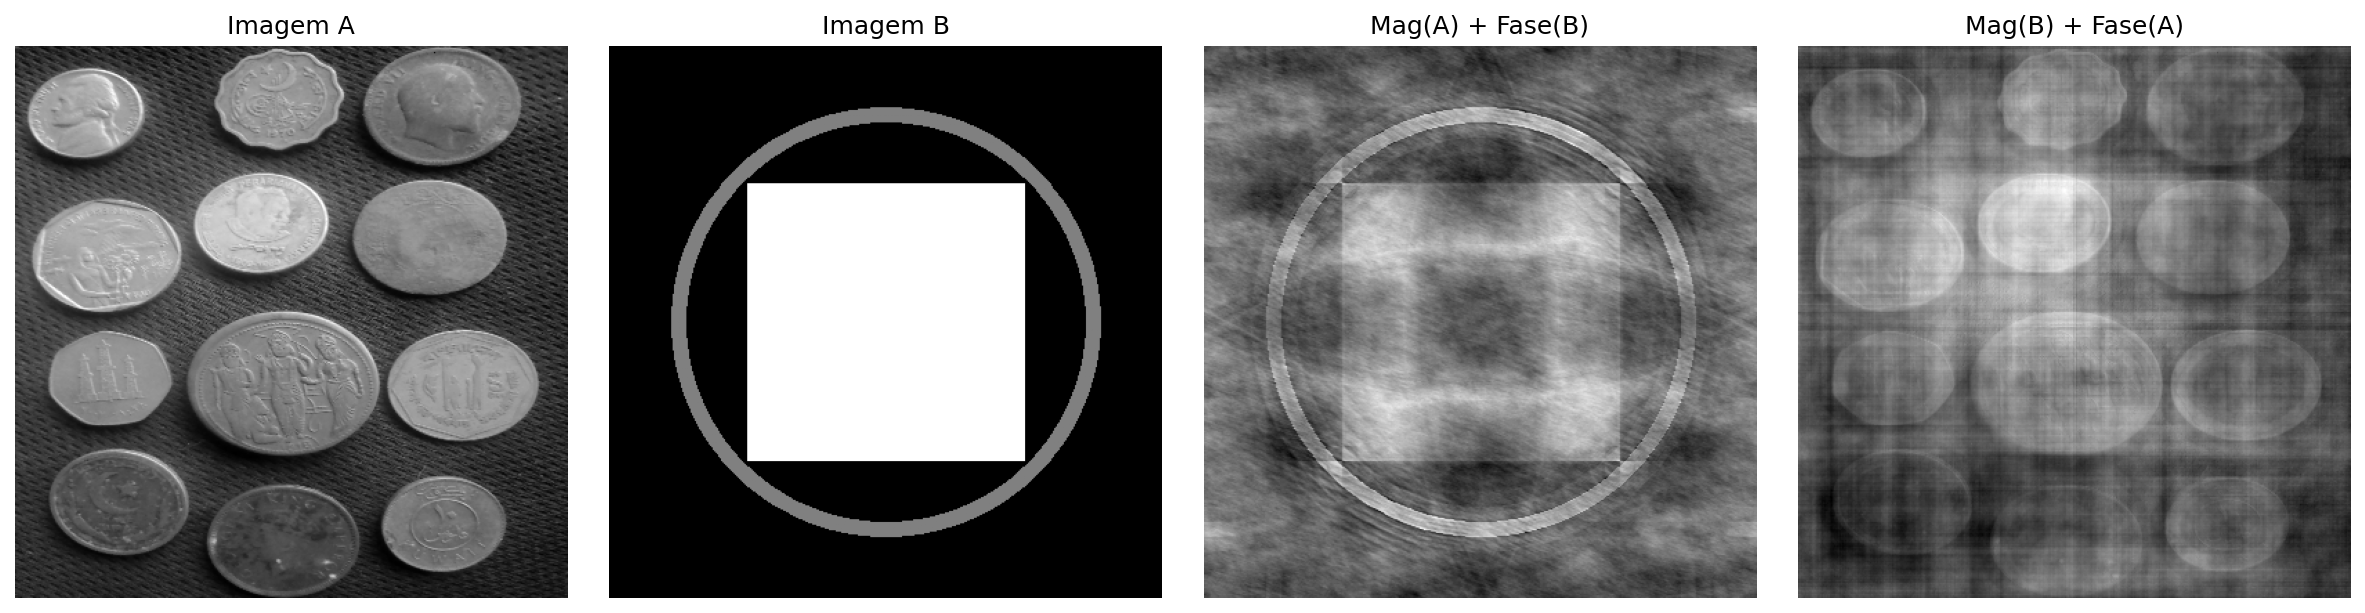

💡 Interpretação: Observe que a estrutura (formas) segue a FASE, não a magnitude.


In [ ]:
# ── Experimento: A Importância da Fase ───────────────────────────────────────
url_a = "https://upload.wikimedia.org/wikipedia/commons/2/25/GAZI.MD.AHAD_11.jpg"
img_a = mm.gray(np.array(mm.read(url_a, pil=True)))
img_a = cv2.resize(img_a, (400, 400))

# Criar uma imagem B sintética (padrão geométrico)
img_b = np.zeros((400, 400), dtype=np.uint8)
cv2.rectangle(img_b, (100, 100), (300, 300), 255, -1)
cv2.circle(img_b, (200, 200), 150, 128, 10)

FA = np.fft.fft2(img_a)
FB = np.fft.fft2(img_b)

# Troca de Fase
rec_A_mag_B_fase = np.real(np.fft.ifft2(np.abs(FA) * np.exp(1j * np.angle(FB))))
rec_B_mag_A_fase = np.real(np.fft.ifft2(np.abs(FB) * np.exp(1j * np.angle(FA))))

mm.show(
    [img_a, img_b, rec_A_mag_B_fase, rec_B_mag_A_fase],
    titles=["Imagem A", "Imagem B", "Mag(A) + Fase(B)", "Mag(B) + Fase(A)"],
    cols=4, figsize=(16, 4)
)

print("💡 Interpretação: Observe que a estrutura (formas) segue a FASE, não a magnitude.")

### Simulação Interativa: Construindo Sinais
Abaixo, um simulador interativo para visualizar como a soma de senoides (Fourier) compõe um sinal. Experimente adicionar harmônicos para ver a formação de uma onda quadrada.

In [ ]:
HTML('''
<div style="border: 1px solid #ddd; padding: 20px; border-radius: 10px; background: #f9f9f9;">
    <h4>Simulador de Síntese de Fourier</h4>
    <canvas id="fourierCanvas" width="600" height="200" style="background: white; border: 1px solid #ccc;"></canvas>
    <div style="margin-top: 10px;">
        <label>Número de Harmônicos: <span id="harmValue">1</span></label><br>
        <input type="range" id="harmSlider" min="1" max="50" value="1" style="width: 100%;">
    </div>
    <script>
        (function() {
            const canvas = document.getElementById('fourierCanvas');
            const ctx = canvas.getContext('2d');
            const slider = document.getElementById('harmSlider');
            const valDisp = document.getElementById('harmValue');
            
            function draw() {
                const n = parseInt(slider.value);
                valDisp.innerText = n;
                ctx.clearRect(0, 0, canvas.width, canvas.height);
                
                ctx.beginPath();
                ctx.strokeStyle = '#2563eb';
                ctx.lineWidth = 2;
                
                for (let x = 0; x < canvas.width; x++) {
                    let y = 0;
                    let t = (x / canvas.width) * Math.PI * 2;
                    for (let i = 1; i <= n; i++) {
                        let k = 2 * i - 1;
                        y += (1 / k) * Math.sin(k * t * 2);
                    }
                    let plotY = canvas.height/2 - y * 60;
                    if (x === 0) ctx.moveTo(x, plotY);
                    else ctx.lineTo(x, plotY);
                }
                ctx.stroke();
                
                ctx.beginPath();
                ctx.strokeStyle = '#ccc';
                ctx.setLineDash([5, 5]);
                ctx.moveTo(0, canvas.height/2);
                ctx.lineTo(canvas.width, canvas.height/2);
                ctx.stroke();
                ctx.setLineDash([]);
            }
            
            slider.oninput = draw;
            draw();
        })();
    </script>
</div>
''')

## 2. Filtragem no Domínio da Frequência

### O Teorema da Convolução
O fundamento da filtragem espectral é a relação elegante:
$$
g(x,y) = f(x,y) * h(x,y) \iff G(u,v) = F(u,v) \cdot H(u,v)
$$
Filtrar uma imagem no domínio da frequência consiste em **esculpir o espectro**: multiplicamos cada frequência por um peso $H(u,v)$ (Função de Transferência).

### Filtros Passa-Baixa (Suavização)
1. **Ideal:** Corte abrupto. Causa *ringing* (oscilações de Gibbs).
2. **Butterworth:** Transição controlada pela ordem $n$. Equilíbrio entre suavidade e corte.
3. **Gaussiano:** Transição perfeitamente suave. Sem *ringing*.

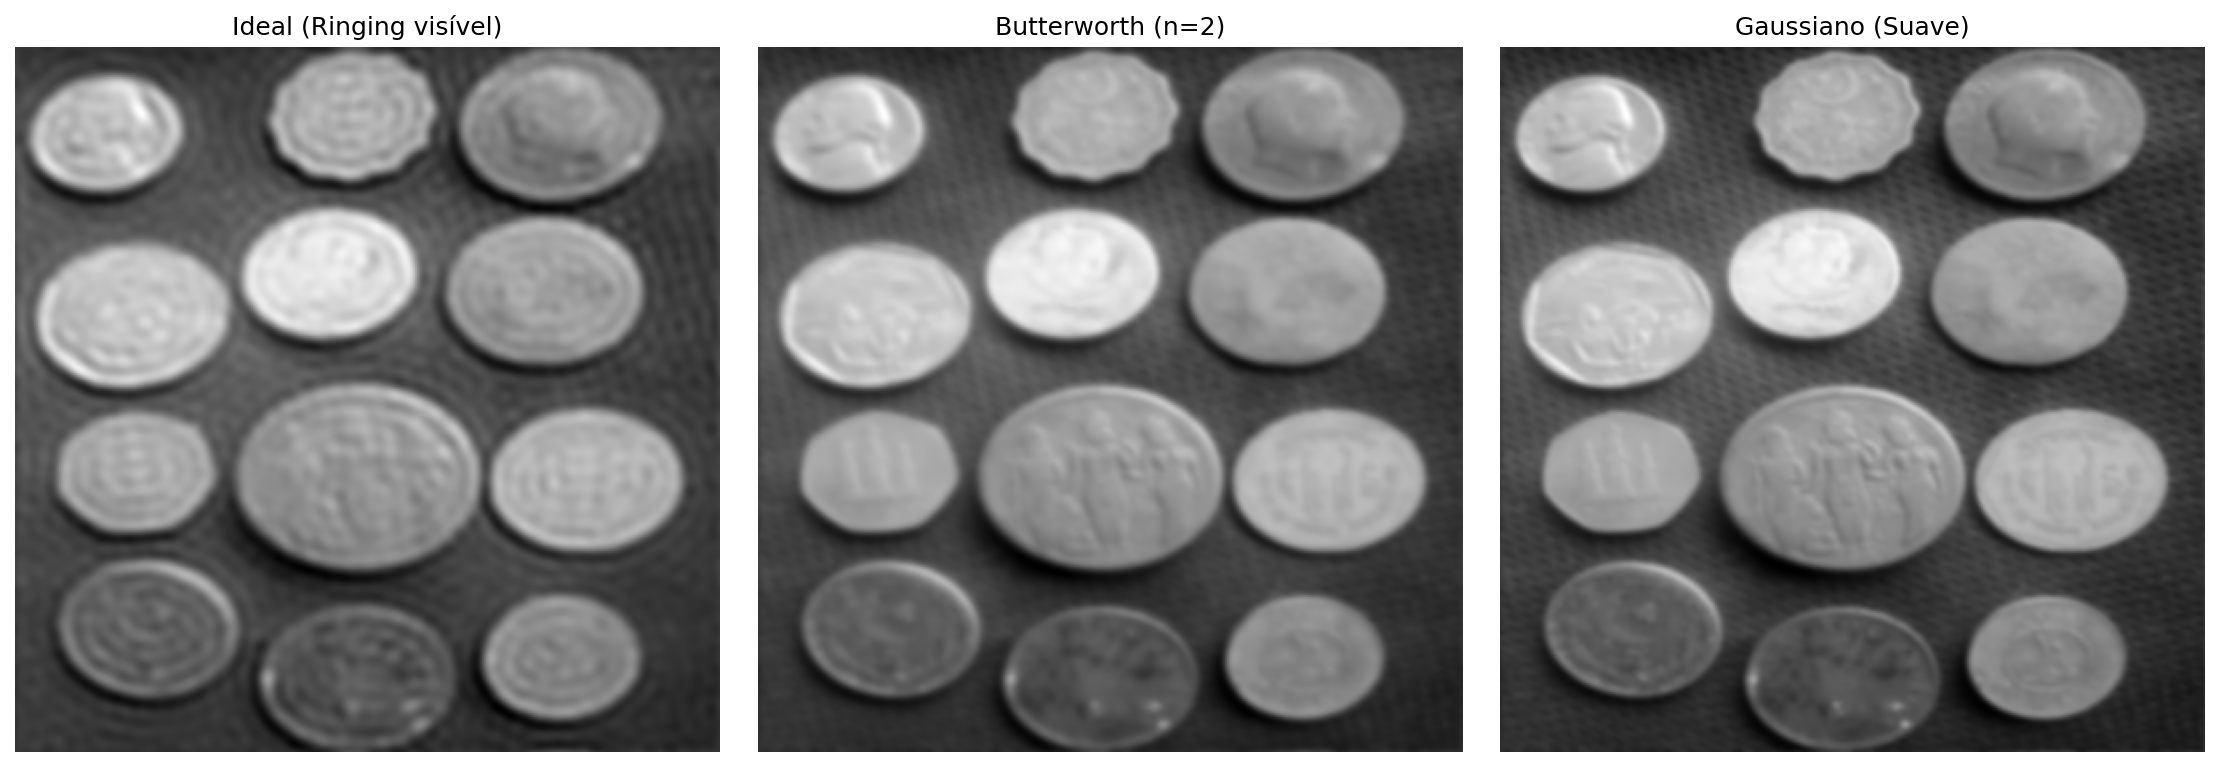

In [ ]:
def create_filters(M, N, D0=30, n=2):
    u = np.arange(M) - M // 2
    v = np.arange(N) - N // 2
    V, U = np.meshgrid(v, u)
    D = np.sqrt(U**2 + V**2)
    
    H_ideal = (D <= D0).astype(float)
    H_bw = 1 / (1 + (D / D0)**(2 * n))
    H_gauss = np.exp(-(D**2) / (2 * D0**2))
    return H_ideal, H_bw, H_gauss

M, N = img_a.shape
Hi, Hb, Hg = create_filters(M, N, D0=40)

def apply_f(img, H):
    F = np.fft.fftshift(np.fft.fft2(img))
    return np.real(np.fft.ifft2(np.fft.ifftshift(F * H)))

res_i = apply_f(img_a, Hi)
res_b = apply_f(img_a, Hb)
res_g = apply_f(img_a, Hg)

mm.show(
    [res_i, res_b, res_g],
    titles=["Ideal (Ringing visível)", "Butterworth (n=2)", "Gaussiano (Suave)"],
    cols=3, figsize=(15, 5)
)

::: {.callout-note}
### Síntese: Domínio da Frequência
* **O Espaço e a Frequência** são faces da mesma moeda. O que é convolução lenta no espaço torna-se multiplicação rápida na frequência.
* **O Fenômeno de Gibbs** (ringing) é o preço matemático de tentar cortar frequências de forma abrupta.
* **Filtros Notch** são os cirurgiões do espectro: removem ruídos periódicos específicos sem borrar o restante da imagem.
:::

## 3. Wavelets: Frequência com Localização

### Por que Wavelets?
A Transformada de Fourier é **global**. Se uma nota musical soa no início de uma música, a DFT dirá que essa frequência existe, mas não saberá dizer **quando**. 

Nas imagens, as **Wavelets (Ondaletas)** permitem analisar o conteúdo de frequência em diferentes escalas e posições simultaneamente. Elas substituem as senoides infinitas por pequenas ondas de suporte finito.

### Decomposição em Subbandas
A Transformada Wavelet Discreta (DWT) divide a imagem em:
* **LL (Aproximação):** A "alma" da imagem em baixa resolução.
* **LH, HL, HH (Detalhes):** Bordas horizontais, verticais e diagonais.

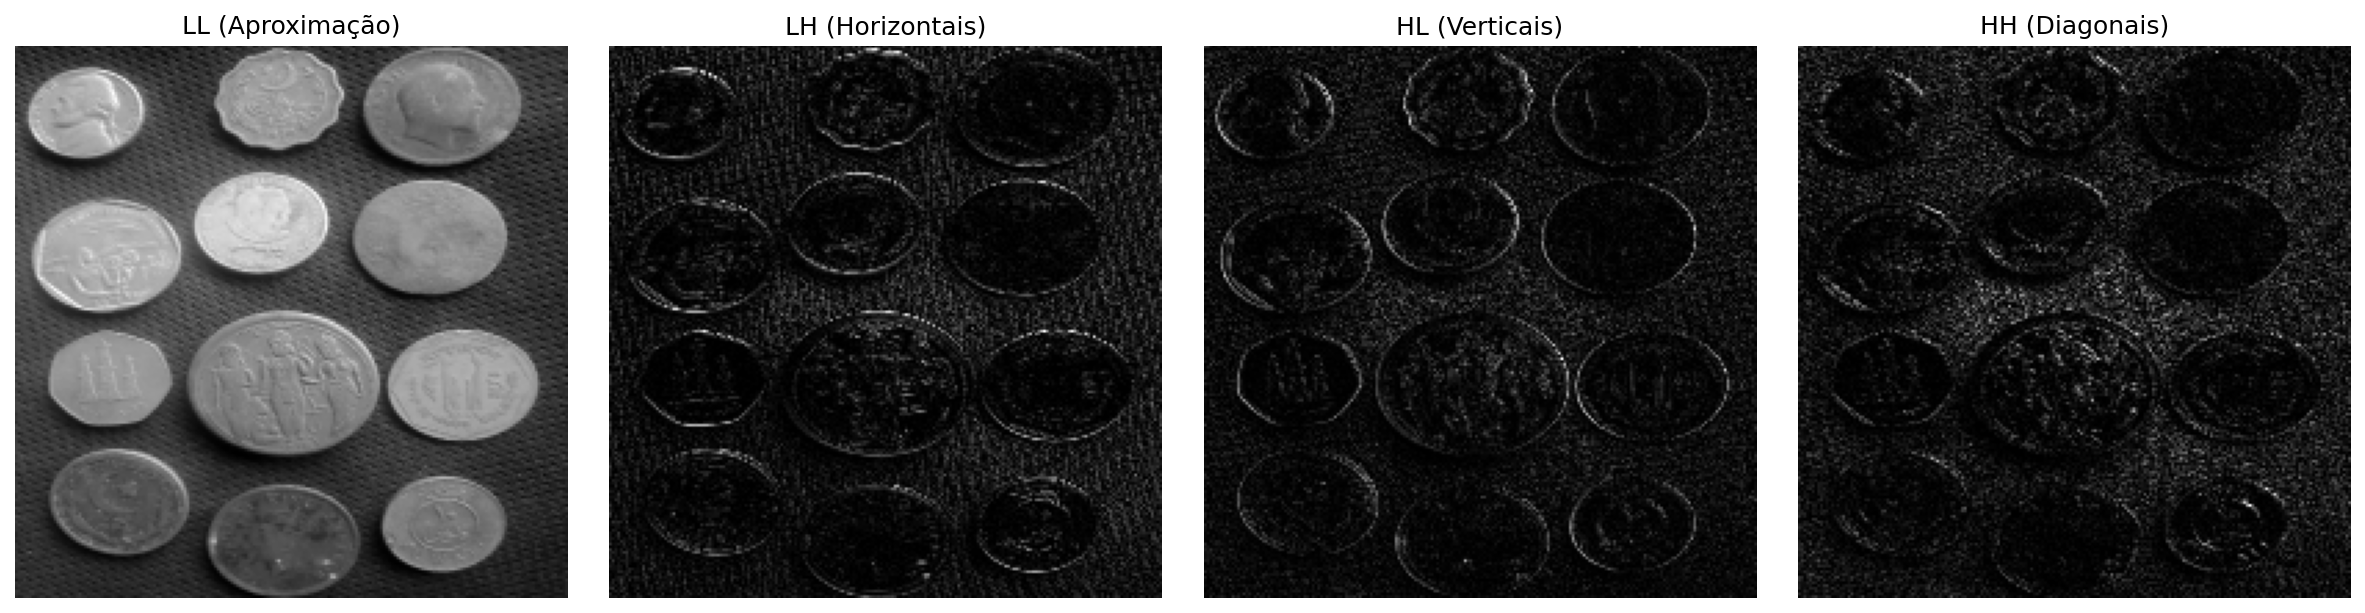

💡 Note como as subbandas de detalhe funcionam como detectores de borda orientados.


In [ ]:
import pywt

coeffs = pywt.dwt2(img_a.astype(float), 'haar')
LL, (LH, HL, HH) = coeffs

def norm_w(d): return cv2.normalize(np.abs(d), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

mm.show(
    [norm_w(LL), norm_w(LH), norm_w(HL), norm_w(HH)],
    titles=["LL (Aproximação)", "LH (Horizontais)", "HL (Verticais)", "HH (Diagonais)"],
    cols=4, figsize=(16, 4)
)

print("💡 Note como as subbandas de detalhe funcionam como detectores de borda orientados.")

### Fourier vs. Wavelets: Um Comparativo Visual

| Característica | Fourier (DFT) | Wavelets (DWT) |
|:---|:---|:---|
| **Base** | Senoides infinitas | Ondaletas compactas |
| **Localização** | Apenas Frequência | Frequência + Espaço |
| **Resolução** | Única escala | Multirresolução |
| **Uso Principal** | Filtragem, Compressão (DCT) | Denosing, Compressão (JPEG2000) |

## 4. Compressão de Imagens: A Ciência do Descarte Inteligente

A compressão não é apenas sobre reduzir bits; é sobre entender o que o **Sistema Visual Humano (SVH)** ignora.

### Redundâncias Exploradas
1. **Espacial:** Pixels vizinhos costumam ser parecidos.
2. **Psicovisual:** O olho humano é menos sensível a erros em altas frequências e variações de cor (crominância) do que em brilho (luminância).

### O Fluxo JPEG
1. **DCT (Transformada de Cossenos):** Compacta a energia nos coeficientes de baixa frequência.
2. **Quantização:** O passo onde a informação é perdida. Divide-se os coeficientes por uma matriz baseada na sensibilidade humana.
3. **Codificação:** Compactação sem perda dos dados restantes.

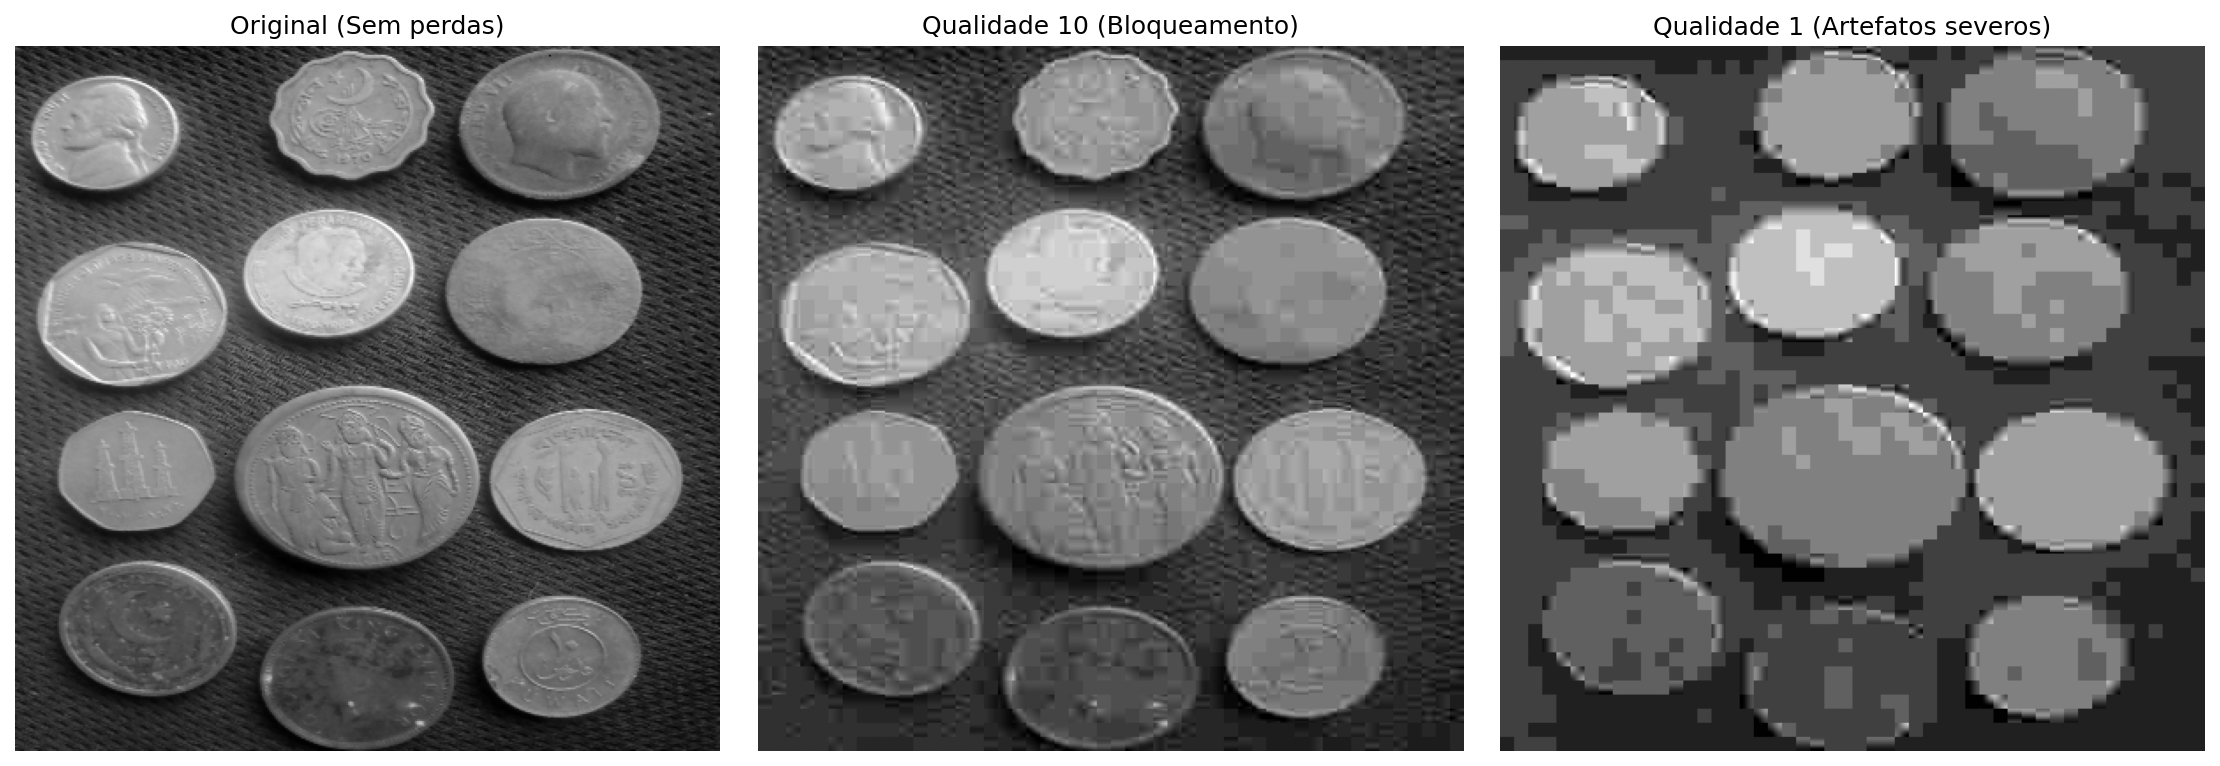

In [ ]:
def test_jpeg_quality(img, quality):
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    _, enc = cv2.imencode('.jpg', img, encode_param)
    dec = cv2.imdecode(enc, 1)
    return mm.gray(dec)

q10 = test_jpeg_quality(img_a, 10)
q1 = test_jpeg_quality(img_a, 1)

mm.show(
    [img_a, q10, q1],
    titles=["Original (Sem perdas)", "Qualidade 10 (Bloqueamento)", "Qualidade 1 (Artefatos severos)"],
    cols=3, figsize=(15, 5)
)

::: {.callout-tip}
### Conclusão do Capítulo
Neste capítulo, vimos que as imagens podem ser interpretadas como sinais oscilatórios. A **DFT** nos deu as ferramentas para filtrar ruídos e entender a estrutura global. As **Wavelets** nos permitiram focar em detalhes locais e escalas múltiplas. Por fim, a **Compressão** nos ensinou que, ao conhecer as limitações da percepção humana, podemos descartar dados massivos sem perder a essência visual.
:::